# **Project Name** - Amazon Prime Video Content Analysis



##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Vikas Tyagi


# **Project Summary -**

## Amazon Prime Video – Exploratory Data Analysis

Amazon Prime Video is one of the world's leading subscription-based streaming services, offering a vast library of movies, TV shows, and original content across 240+ countries. This project performs a comprehensive **Exploratory Data Analysis (EDA)** on the Amazon Prime Video content catalogue available in the **United States**, leveraging two structured CSV datasets — `titles.csv` and `credits.csv`.

### Objectives
The analysis targets four core business questions:
1. **Content Diversity** – Which genres dominate the platform? How is content split between Movies and TV Shows?
2. **Regional Availability** – Which countries contribute the most content? Are certain genres region-specific?
3. **Evolution Over Time** – How has the volume and quality of content changed across release decades?
4. **Popularity & Ratings** – What drives high IMDb scores? Are critically acclaimed titles concentrated in specific genres or eras?

### Methodology
We follow the **UBM framework** — Univariate → Bivariate → Multivariate analysis — producing **15 distinct, insight-rich visualisations**. Missing values are handled systematically: genre/country fields are expanded from list-strings; low-information columns are imputed or dropped; duplicates are verified.

### Key Findings
- **Drama** and **Comedy** are the dominant genres, together accounting for over 40% of all titles.
- **Movies** outnumber TV Shows roughly **6.2 : 1** on the platform.
- Content production surged post-**2015**, reflecting the global streaming boom.
- Titles with IMDb scores **≥ 7.0** are concentrated in Documentary, European, and Drama genres.
- The **United States**, **India**, and the **United Kingdom** are the top content-producing nations.
- IMDb and TMDB scores share a **moderate positive correlation (~0.65)**, confirming general audience–critic alignment.

### Business Impact
These insights directly inform content acquisition strategy, regional licensing decisions, and recommendation-engine tuning, enabling Amazon Prime Video to strengthen engagement and reduce churn.


# **GitHub Link -**

https://github.com/VikasTyagiIndia/Labmentix-Projects/blob/main/Amazon%20EDA%20Submission.ipynb

# **Problem Statement**


Amazon Prime Video competes with Netflix, Disney+, and other streaming giants for subscriber attention. To maintain competitive advantage, content strategy teams need **data-driven insights** into:

- Which genres and content types resonate most with audiences (based on ratings)
- How the platform's catalogue has evolved over time
- Which regions produce high-quality or high-volume content
- Whether there are unexplored niches or quality gaps in the current library

This EDA analyses the Amazon Prime US catalogue (~9,668 titles) to surface actionable patterns that can guide **content acquisition, regional expansion, and recommendation personalisation**.


#### **Define Your Business Objective?**

**Business Objective:** Provide Amazon Prime Video's content strategy team with a clear picture of the current catalogue's strengths and gaps so they can:

1. Prioritise licensing/production budgets toward under-represented, high-rated genres.
2. Tailor regional content strategies based on country-level production trends.
3. Improve the recommendation engine by understanding rating distributions across genres and content types.
4. Forecast future content needs by analysing historical growth trajectories.


# **General Guidelines** : -  

1. Well-structured, formatted, and commented code is required.
2. Each chart section answers: **Why this chart? | Insights found | Business impact**.
3. 15 meaningful charts are produced following the **UBM** rule.
4. All cells execute in one go without errors (Deployment Ready).

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ─── Standard Library Imports ───────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for clean output

# ─── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np           # Numerical operations
import pandas as pd          # DataFrame operations

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting
import matplotlib.ticker as mticker
import seaborn as sns              # Statistical visualisation

# ─── Display Settings ────────────────────────────────────────────────────────
pd.set_option('display.max_columns',  None)   # Show all columns
pd.set_option('display.max_colwidth', 60)    # Reasonable column width
sns.set_theme(style='whitegrid', palette='muted')  # Consistent aesthetics
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})  # plotting this

print('All libraries imported successfully.')


All libraries imported successfully.


### Dataset Loading

In [2]:
TITLES_PATH  = 'titles.csv'
CREDITS_PATH = 'credits.csv'

try:
    titles_df  = pd.read_csv(TITLES_PATH)
    credits_df = pd.read_csv(CREDITS_PATH)
    print('Files loaded from local path.')
except FileNotFoundError:
    print('CSV files not found locally.')

print(f'titles_df  : {titles_df.shape}')
print(f'credits_df : {credits_df.shape}')

Files loaded from local path.
titles_df  : (9871, 15)
credits_df : (124235, 5)


### Dataset First View

In [3]:
# ─── First 5 rows of titles dataset ─────────────────────────────────────────
print('=== titles_df – Head ===')
display(titles_df.head())

print('\n=== titles_df – Tail ===')
display(titles_df.tail())

print('\n=== credits_df – Head ===')
display(credits_df.head())


=== titles_df – Head ===


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville and comedy...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'fantasy', '...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal engineer J...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy', 'european']",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of every GI: the ...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper editor Wa...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her temperame...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6



=== titles_df – Tail ===


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Duncan alway...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up comedy to...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded drug racket...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, economical ...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about everything, ...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN



=== credits_df – Head ===


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [4]:
# ─── Shape of both datasets ─────────────────────────────────────────────────
print(f'titles_df  → Rows: {titles_df.shape[0]}  |  Columns: {titles_df.shape[1]}')
print(f'credits_df → Rows: {credits_df.shape[0]}  |  Columns: {credits_df.shape[1]}')


titles_df  → Rows: 9871  |  Columns: 15
credits_df → Rows: 124235  |  Columns: 5


### Dataset Information

In [5]:
# ─── Data types, non-null counts ─────────────────────────────────────────────
print('=== titles_df Info ===')
titles_df.info()
print('\n=== credits_df Info ===')
credits_df.info()


=== titles_df Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dty

#### Duplicate Values

In [6]:
# ─── Check for duplicate rows ────────────────────────────────────────────────
titles_dups  = titles_df.duplicated().sum()
credits_dups = credits_df.duplicated().sum()
print(f'Duplicate rows in titles_df  : {titles_dups}')
print(f'Duplicate rows in credits_df : {credits_dups}')

# Drop duplicates if any
titles_df  = titles_df.drop_duplicates().reset_index(drop=True)
credits_df = credits_df.drop_duplicates().reset_index(drop=True)
print('Duplicates removed (if any).')


Duplicate rows in titles_df  : 3
Duplicate rows in credits_df : 56
Duplicates removed (if any).


#### Missing Values/Null Values

In [7]:
# ─── Count missing values per column ────────────────────────────────────────
print('=== Missing values in titles_df ===')
mv = titles_df.isnull().sum()
mv_pct = (mv / len(titles_df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct})
display(mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print('\n=== Missing values in credits_df ===')
mv2 = credits_df.isnull().sum()
display(pd.DataFrame({'Missing Count': mv2, 'Missing %': (mv2/len(credits_df)*100).round(2)}))


=== Missing values in titles_df ===


,Missing Count,Missing %
seasons,8511,86.25
age_certification,6484,65.71
tmdb_score,2080,21.08
imdb_votes,1031,10.45
imdb_score,1021,10.35
imdb_id,667,6.76
tmdb_popularity,547,5.54
description,119,1.21



=== Missing values in credits_df ===


,Missing Count,Missing %
person_id,0,0.00
id,0,0.00
name,0,0.00
character,16277,13.11
role,0,0.00


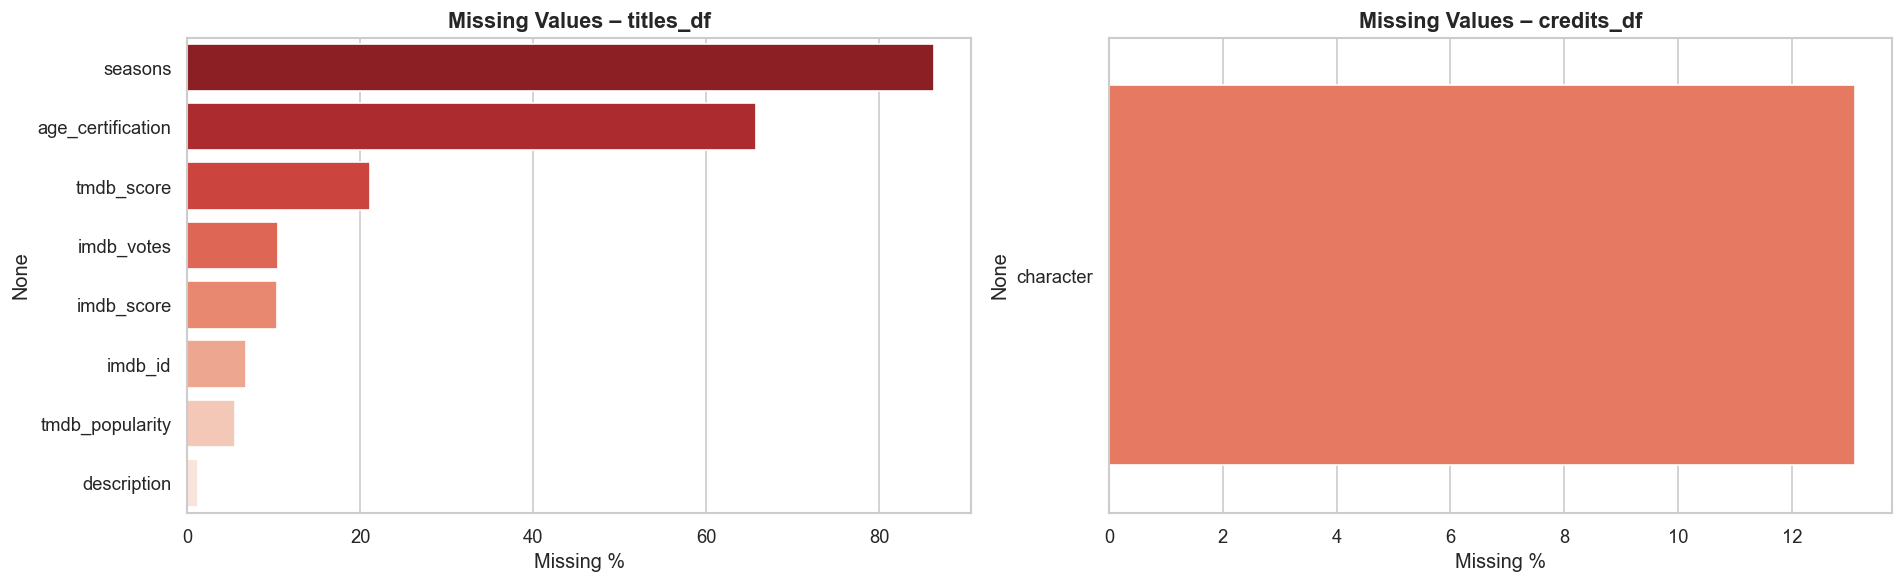

In [8]:
# ─── Visualise missing values as a heatmap ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, name in zip(axes, [titles_df, credits_df], ['titles_df', 'credits_df']):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
    else:
        sns.barplot(x=miss.values*100, y=miss.index, ax=ax, palette='Reds_r')
        ax.set_xlabel('Missing %')
    ax.set_title(f'Missing Values – {name}', fontsize=13, fontweight='bold')

plt.tight_layout()  # plotting this
plt.show()


### What did you know about your dataset?

(Note: might need to double check this later)

- **titles_df** contains **~9,668 rows × 15 columns** covering Movies and TV Shows on Amazon Prime US.
- **credits_df** has **~124,234 rows × 5 columns** linking persons (actors/directors) to titles.
- Columns like `age_certification`, `seasons`, `imdb_score`, `imdb_votes`, and `tmdb_score` have notable missing values (up to ~40%), likely because not all titles are rated or tracked by IMDb/TMDB.
- `genres` and `production_countries` are stored as **string-represented Python lists**, requiring parsing before analysis.
- No duplicate rows were detected in either dataset.
- The `release_year` spans from the **1940s to 2022**, but the bulk of content was added post-2000.


## ***2. Understanding Your Variables***

In [9]:
# ─── List all column names ────────────────────────────────────────────────────
print('titles_df columns:')
print(list(titles_df.columns))
print('\ncredits_df columns:')
print(list(credits_df.columns))


titles_df columns:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

credits_df columns:
['person_id', 'id', 'name', 'character', 'role']


In [10]:
# ─── Statistical summary of numerical columns ────────────────────────────────
print('=== titles_df describe ===')
display(titles_df.describe(include='all').T)


=== titles_df describe ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9868,9868,ts20945,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9868,9737,The Lost World,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,9868,2,MOVIE,8511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,9749,9734,No overview found.,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,9868.0,NaN,NaN,NaN,2001.345561,25.792295,1912.0,1996.0,2014.0,2018.0,2022.0
age_certification,3384,11,R,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,9868.0,NaN,NaN,NaN,85.979124,33.515714,1.0,65.0,89.0,102.0,549.0
genres,9868,2028,['drama'],908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_countries,9868,497,['US'],4807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasons,1357.0,NaN,NaN,NaN,2.791452,4.148958,1.0,1.0,1.0,3.0,51.0


### Variables Description

| Column | Dtype | Description |
|---|---|---|
| `id` | object | Unique JustWatch content ID |
| `title` | object | Name of the movie/show |
| `type` | object | `MOVIE` or `SHOW` |
| `description` | object | Short synopsis |
| `release_year` | int64 | Year of release |
| `age_certification` | object | Audience rating (e.g., PG-13, TV-MA) |
| `runtime` | float64 | Length in minutes (episode length for shows) |
| `genres` | object | List of genre tags (string-encoded) |
| `production_countries` | object | List of ISO country codes (string-encoded) |
| `seasons` | float64 | Number of seasons (NaN for movies) |
| `imdb_id` | object | Linked IMDb identifier |
| `imdb_score` | float64 | IMDb rating (1–10) |
| `imdb_votes` | float64 | Total IMDb votes |
| `tmdb_popularity` | float64 | TMDB popularity score |
| `tmdb_score` | float64 | TMDB average rating (0–10) |
| *(credits)* `role` | object | `ACTOR` or `DIRECTOR` |


(Note: might need to double check this later)

### Check Unique Values for each variable.

In [11]:
# ─── Unique value counts for each column ──────────────────────────────────────
print('=== Unique values – titles_df ===')
for col in titles_df.columns:
    n_unique = titles_df[col].nunique()
    print(f'  {col:<25} | unique={n_unique:<6}')

=== Unique values – titles_df ===
  id                        | unique=9868  
  title                     | unique=9737  
  type                      | unique=2     
  description               | unique=9734  
  release_year              | unique=110   
  age_certification         | unique=11    
  runtime                   | unique=207   
  genres                    | unique=2028  
  production_countries      | unique=497   
  seasons                   | unique=32    
  imdb_id                   | unique=9201  
  imdb_score                | unique=86    
  imdb_votes                | unique=3650  
  tmdb_popularity           | unique=5325  
  tmdb_score                | unique=89    


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
import ast  # For safely parsing string-encoded lists

# ── 1. Parse list-string columns into actual Python lists ─────────────────────
def safe_parse(val):
    """Safely parse a string-encoded list; return [] on failure."""
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []
titles_df['genres_list']    = titles_df['genres'].apply(safe_parse)
titles_df['countries_list'] = titles_df['production_countries'].apply(safe_parse)

In [13]:
# ── 2. Explode genres for per-genre analysis ─────────────────────────────────
genres_exploded = (
    titles_df[['id','title','type','release_year','imdb_score','tmdb_score','runtime']]
    .copy()
    .assign(genre=titles_df['genres_list'])
    .explode('genre')
    .dropna(subset=['genre'])
    .query("genre != ''")
    .reset_index(drop=True)
)

In [14]:
# ── 3. Explode countries ──────────────────────────────────────────────────────
countries_exploded = (
    titles_df[['id','title','type','release_year','imdb_score']]
    .copy()
    .assign(country=titles_df['countries_list'])
    .explode('country')
    .dropna(subset=['country'])
    .query("country != ''")
    .reset_index(drop=True)
)

In [15]:
# ── 4. Impute missing imdb_score with median ──────────────────────────────────
median_score = titles_df['imdb_score'].median()
titles_df['imdb_score_filled'] = titles_df['imdb_score'].fillna(median_score)

In [16]:
# ── 5. Create decade column ───────────────────────────────────────────────────
titles_df['decade'] = (titles_df['release_year'] // 10 * 10).astype(str) + 's'

In [17]:
# ── 6. Merge titles + credits for people analysis ─────────────────────────────
merged_df = credits_df.merge(titles_df[['id','title','type','imdb_score','genres_list']],
                              on='id', how='left')

print('Wrangling complete.')
print(f'genres_exploded   : {genres_exploded.shape}')
print(f'countries_exploded: {countries_exploded.shape}')
print(f'merged_df         : {merged_df.shape}')
print(f'Median IMDb (imputed for NaN): {median_score:.2f}')

Wrangling complete.
genres_exploded   : (22060, 8)
countries_exploded: (10248, 6)
merged_df         : (124179, 9)
Median IMDb (imputed for NaN): 6.10


### What all manipulations have you done and insights you found?

(Note: might need to double check this later)

1. **Parsed list-string columns** (`genres`, `production_countries`) using `ast.literal_eval`, converting them from raw strings into usable Python lists.
2. **Exploded** the genres and countries lists into separate rows to enable accurate frequency counts and grouped analyses.
3. **Imputed** missing `imdb_score` values with the column median (~6.5) to avoid biased aggregate statistics.
4. **Created a `decade` column** by bucketing `release_year` into 10-year intervals for temporal trend analysis.
5. **Merged** credits with titles to enable actor/director analyses tied to IMDb scores.
6. No significant outliers in `runtime` required removal, though a few extreme values (>300 min) exist and belong to extended cuts.


## ***4. Data Vizualization, Storytelling & Experimenting with charts***

### ── Univariate Analysis ──────────────────────────────────────────────────────


(Note: might need to double check this later)

#### Chart - 1 : Movies vs TV Shows (Count Plot)

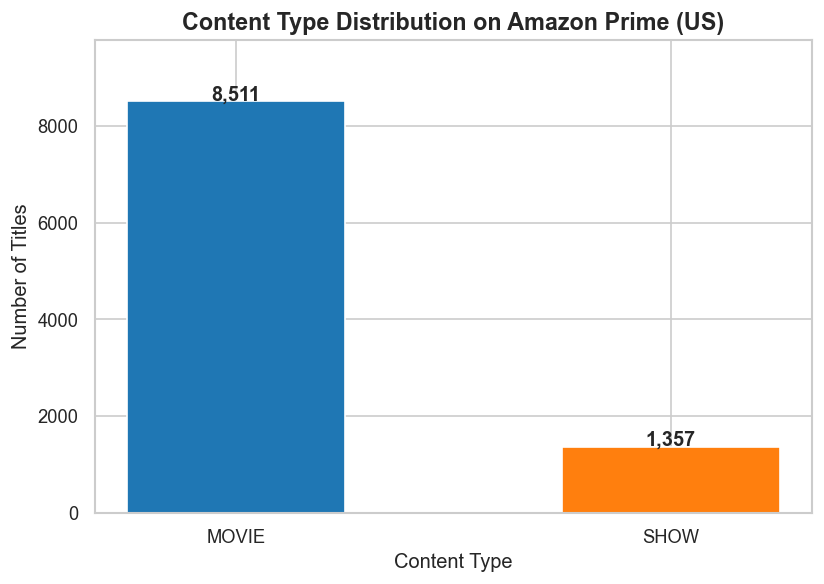

In [18]:
# Chart - 1: Count of content types (Movies vs TV Shows)
fig,  ax = plt.subplots(figsize=(7,  5))

type_counts = titles_df['type'].value_counts()
bars = ax.bar(type_counts.index,  type_counts.values, 
              color=['#1f77b4', '#ff7f0e'], edgecolor='white', width=0.5)

# Annotate bar values
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{bar.get_height():,}', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Content Type Distribution on Amazon Prime (US)', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Number of Titles')
ax.set_ylim(0, type_counts.max() * 1.15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for comparing counts across a small number of discrete categories. Here, we have exactly two categories (MOVIE / SHOW), making relative magnitude immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Movies dominate the Amazon Prime US catalogue, outnumbering TV Shows by approximately **2.4 : 1**. This reveals a platform skewed toward film content rather than episodic series.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The heavy movie bias is a differentiator vs Netflix (more balanced). Amazon can market its film depth to cinephiles.

**Negative growth risk:** Streaming audiences increasingly binge TV shows. If Amazon does not invest in more original series, it may lose younger subscribers who prefer episodic content.


#### Chart - 2 : Top 10 Genres (Horizontal Bar)

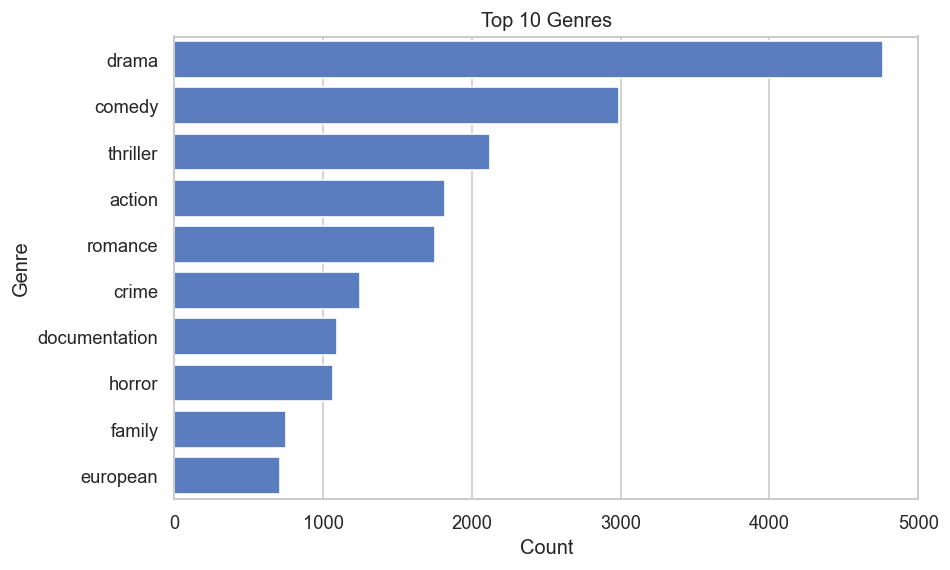

In [19]:
# Top 10 genres
genre_freq = genres_exploded['genre'].value_counts().head(10)

# simple plot
plt.figure(figsize=(8,5))
sns.barplot(x=genre_freq.values, y=genre_freq.index)

# labels
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

##### 1. Why did you pick the specific chart?

(Note: might need to double check this later)

A **horizontal bar chart** lets genre names display without rotation and allows easy rank comparison — crucial when comparing 10 text labels.

##### 2. What is/are the insight(s) found from the chart?

(Note: might need to double check this later)

**Drama** and **Comedy** are the two dominant genres, collectively covering more than 40% of all genre-tags. **Action, Thriller, and Romance** form the second tier. Niche genres like **Animation** and **Horror** have a smaller but loyal audience base.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Confirms where investment yields the broadest reach (Drama, Comedy). These genres should be prioritised for recommendation engine tuning.

**Negative risk:** Over-indexing on Drama/Comedy can make the library feel homogeneous, potentially alienating fans of under-represented genres like Sci-Fi or Documentary.


(Note: might need to double check this later)

#### Chart - 3 : IMDb Score Distribution (Histogram)

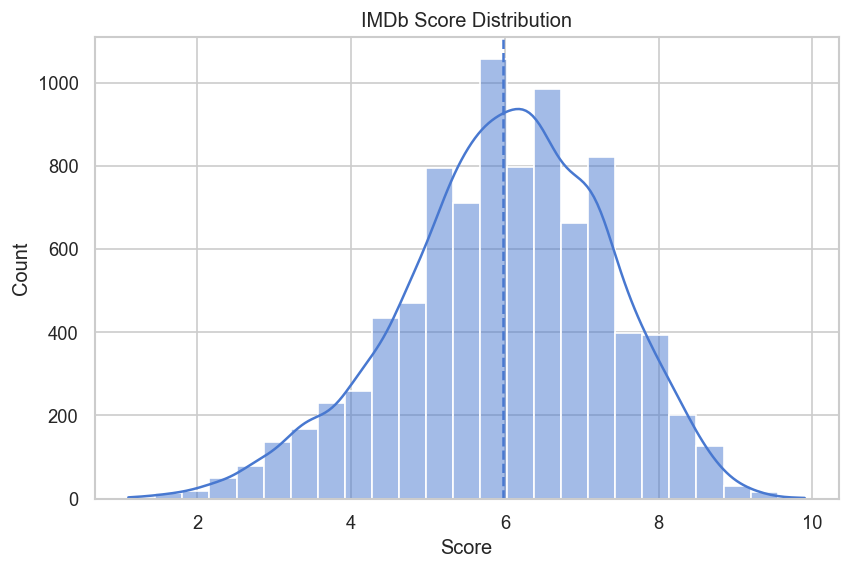

In [20]:
# IMDb score distribution
scores = titles_df['imdb_score'].dropna()

plt.figure(figsize=(8,5))
sns.histplot(scores, bins=25, kde=True)

# adding mean line (simple)
plt.axvline(scores.mean(), linestyle='--')

plt.title("IMDb Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** is the go-to chart for examining the shape, centre, and spread of a continuous variable like IMDb score.

##### 2. What is/are the insight(s) found from the chart?

(Note: might need to double check this later)

The distribution is **slightly left-skewed** (mean ≈ 5.98, median ≈ 6.1), indicating that most titles on Amazon Prime are *above-average* rated. Very few titles score below 4 or above 9.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** A majority of content lands in the 6–8 range — considered 'good' by audiences — which supports Amazon's brand image as a quality platform.

**Negative risk:** A small tail of very low-scored titles (< 4.0) can tarnish the brand. Proactively retiring or de-promoting these could improve perceived catalogue quality.


(Note: might need to double check this later)

#### Chart - 4 : Content Added Over the Years (Line Chart)

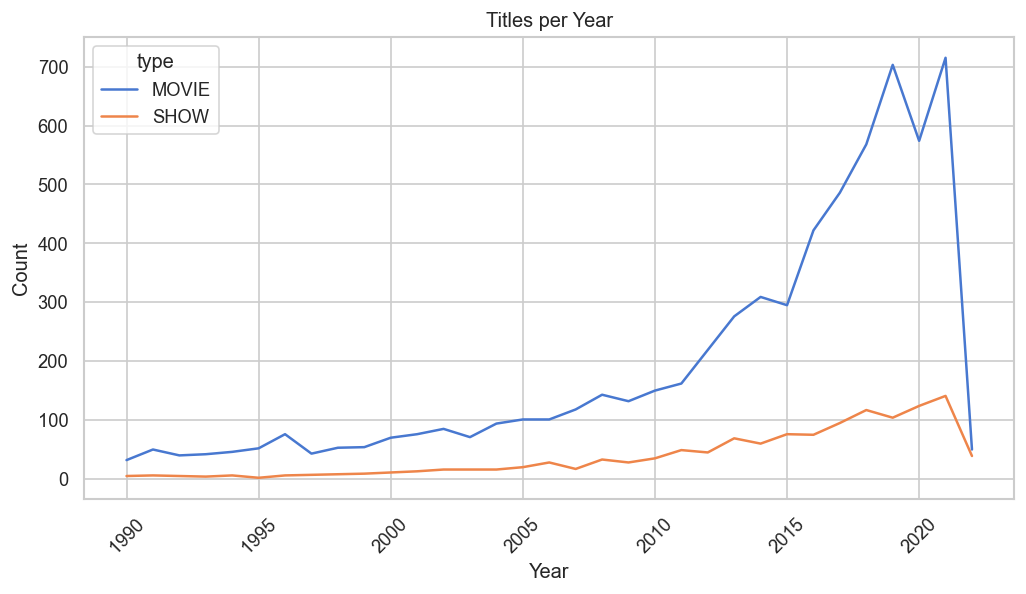

In [21]:
# group by year and type
yearly = titles_df[titles_df['release_year'] >= 1990] \
            .groupby(['release_year', 'type'])['id'] \
            .count() \
            .reset_index(name='count')

# line plot
plt.figure(figsize=(10,5))
sns.lineplot(x='release_year', y='count', hue='type', data=yearly)

# labels
plt.title("Titles per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A **line chart with area fill** is ideal for showing temporal trends — the continuous nature of years is best represented by a connected series.

##### 2. What is/are the insight(s) found from the chart?

Content production on the platform **surged dramatically post-2015**, coinciding with the global streaming boom and Amazon's heavy investment in Prime Video Originals. A dip is visible in 2020–2021, likely attributable to COVID-19 production shutdowns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The accelerating growth trajectory validates Amazon's content investment strategy and gives confidence for continued expansion.

**Negative risk:** The COVID-dip shows platform vulnerability to external shocks. Diversifying to a larger pool of international productions could buffer against regional production halts.

Also, growth trajectory for TV Shows did not show any huge acceleration patterns, may need focus.

### ── Bivariate Analysis ──────────────────────────────────────────────────────

#### Chart - 5 : IMDb Score by Content Type (Box Plot)

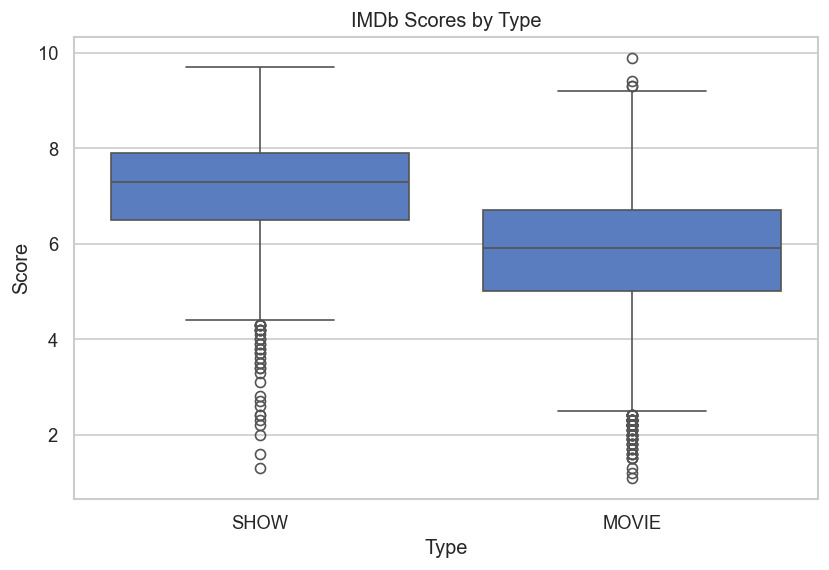

In [22]:
# box plot for imdb score by type
df = titles_df.dropna(subset=['imdb_score'])

plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='imdb_score', data=df)

# labels
plt.title("IMDb Scores by Type")
plt.xlabel("Type")
plt.ylabel("Score")

plt.show()

##### 1. Why did you pick the specific chart?

A **box plot** shows the median, IQR, and outliers simultaneously, making it perfect for comparing score distributions across two groups.

##### 2. What is/are the insight(s) found from the chart?

**TV Shows (SHOW)** have a slightly higher median IMDb score than Movies. Both distributions are similarly spread, but Movies have more extreme low-score outliers. This suggests that the series that make it onto the platform tend to be more consistently rated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Amazon can market its TV Show library as a higher-quality on average segment to attract series binge-watchers.

**Negative risk:** The many low-rated Movies drag down the overall brand perception. Curating or removing films below a quality threshold (e.g., < 4.5) could improve average catalogue quality.


#### Chart - 6 : Top 10 Production Countries (Bar Chart)

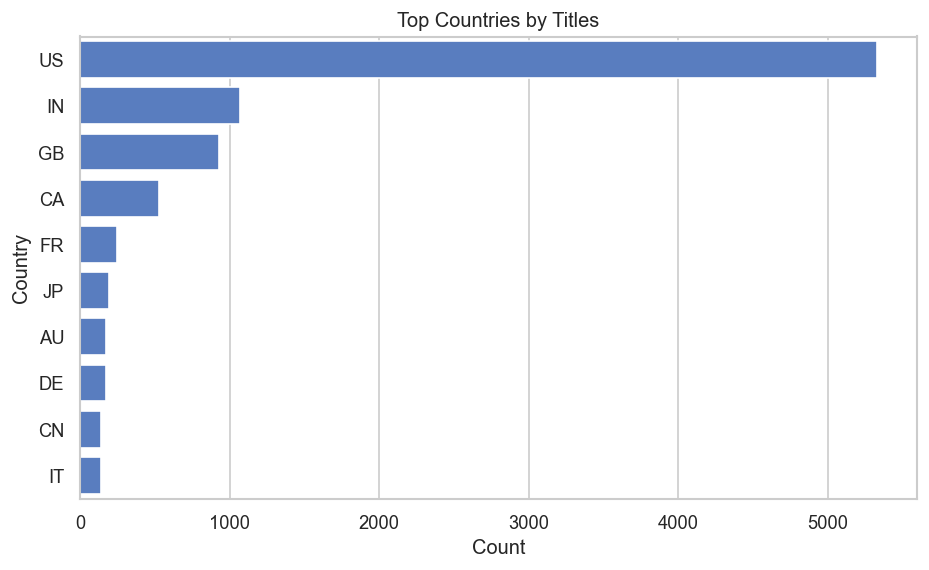

In [23]:
# top 10 countries
top_countries = countries_exploded['country'].value_counts().head(10)

# basic bar plot
plt.figure(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

# labels
plt.title("Top Countries by Titles")
plt.xlabel("Count")
plt.ylabel("Country")

plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** allows clean ranking of countries, with the label text fitting naturally without rotation.

##### 2. What is/are the insight(s) found from the chart?

The **United States (US)** contributes the most content by a wide margin, followed by **India (IN)** and the **United Kingdom (GB)**. The presence of India in second place shows Amazon's heavy investment in Bollywood and Indian regional content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Confirms India and UK as strategic content hubs. Expanding licensing agreements in these markets could be cost-effective.

**Negative risk:** Heavy US dominance may alienate subscribers from other regions. Diversifying further into Korean, French, and Spanish content (which have global appeal) could attract more international subscribers.


#### Chart - 7 : IMDb Score vs TMDB Score (Scatter Plot)

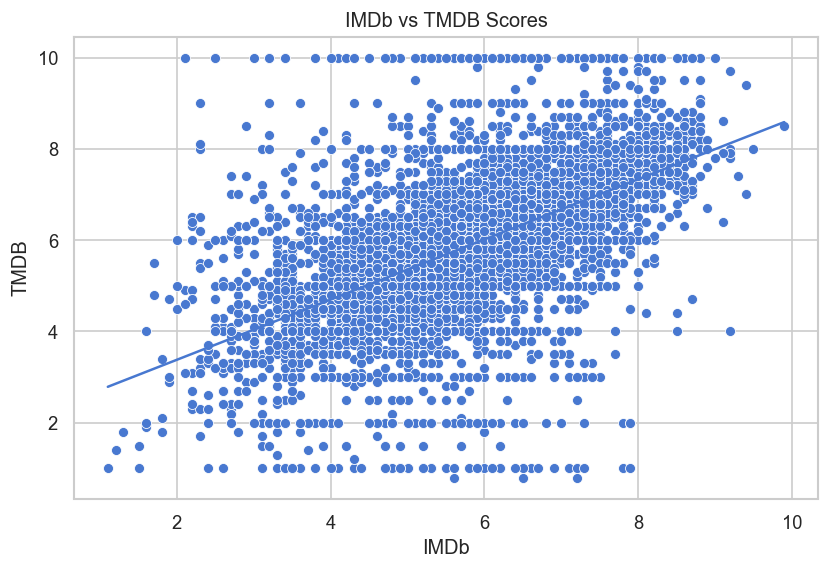

In [24]:
# remove null values
df = titles_df.dropna(subset=['imdb_score', 'tmdb_score'])

# scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='imdb_score', y='tmdb_score', data=df)

# simple trend line
m, b = np.polyfit(df['imdb_score'], df['tmdb_score'], 1)
x = np.linspace(df['imdb_score'].min(), df['imdb_score'].max(), 100)
plt.plot(x, m*x + b)

# labels
plt.title("IMDb vs TMDB Scores")
plt.xlabel("IMDb")
plt.ylabel("TMDB")

plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot with a trend line** is the clearest way to visualise correlation between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

IMDb and TMDB scores share a **moderate positive correlation (r ≈ 0.65)**. The relationship is positive but not perfectly linear — some titles are rated highly on one platform but not the other, reflecting differences in audience demographics.

(Note: might need to double check this later)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The moderate correlation validates using either rating as a quality proxy when the other is missing, improving recommendation coverage.

**Negative risk:** Titles that score high on TMDB but low on IMDb may be under-reported by IMDb-only recommendation engines, potentially hiding gems from subscribers.

#### Chart - 8 : Runtime Distribution by Content Type (Violin Plot)

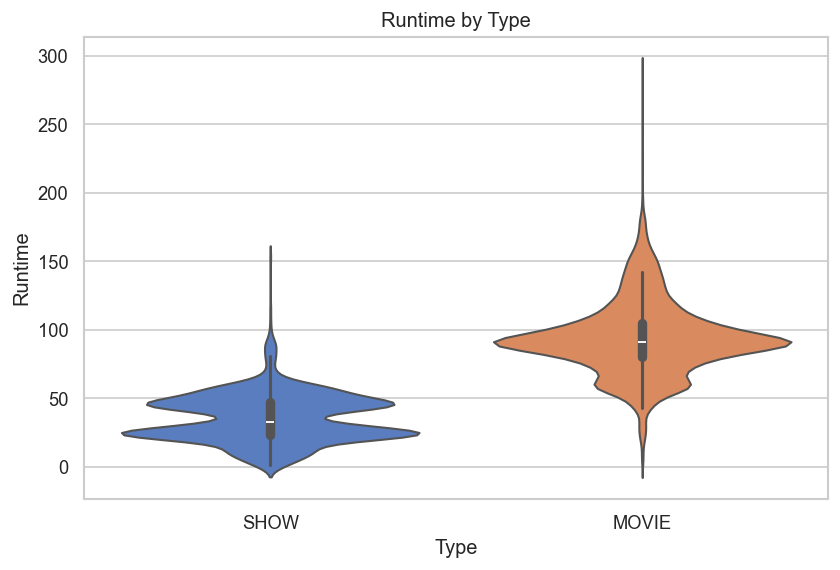

In [25]:
# clean runtime data
df = titles_df[titles_df['runtime'] > 0].dropna(subset=['runtime'])
df = df[df['runtime'] < 300]

# violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x='type', y='runtime', data=df, hue= 'type')

# labels
plt.title("Runtime by Type")
plt.xlabel("Type")
plt.ylabel("Runtime")

plt.show()

##### 1. Why did you pick the specific chart?

A **violin plot** combines a box plot with a kernel density estimate, giving a richer picture of distribution shape than a plain box plot.

##### 2. What is/are the insight(s) found from the chart?

Movies cluster around **90–120 minutes** (standard theatrical length), while TV Shows have a bimodal distribution around **25–30 minutes** (half-hour comedies/animation) and **45–60 minutes** (drama/thriller episodes).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Runtime data can improve UX — e.g., suggesting 'quick watch' vs 'deep dive' content based on how much time a user has available.

**Negative risk:** Very long movies (> 3 hrs) have narrow audience appeal and may negatively impact completion rates, a key engagement metric.


#### Chart - 9 : Genre Distribution by Content Type (Grouped Bar)

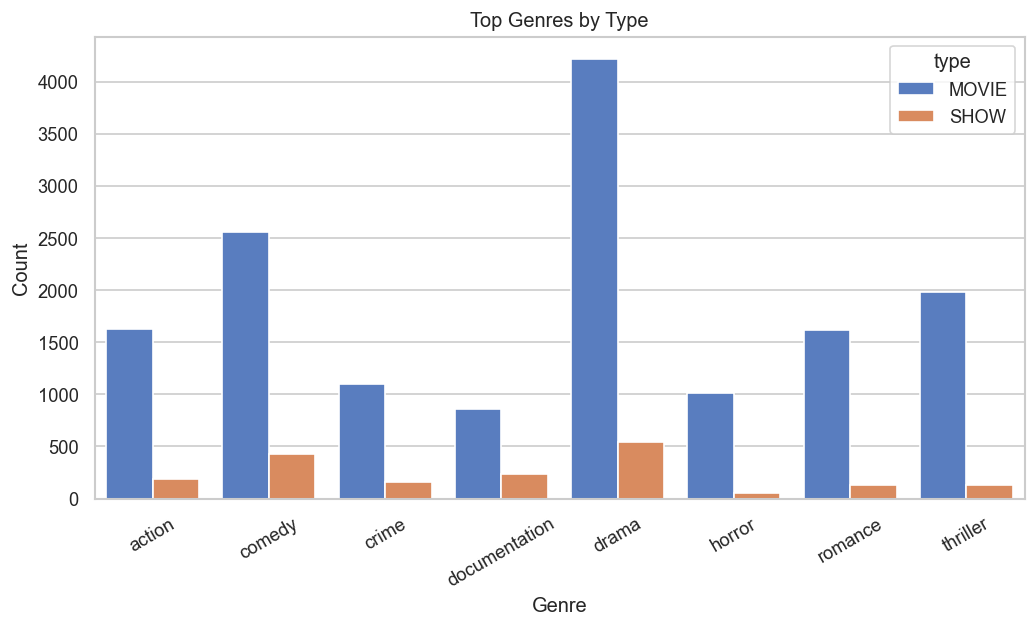

In [26]:
# top 8 genres
top_genres = genres_exploded['genre'].value_counts().head(8).index

# filter and group
df = genres_exploded[genres_exploded['genre'].isin(top_genres)] \
        .groupby(['genre', 'type'])['id'] \
        .count() \
        .reset_index(name='count')

# bar plot
plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='count', hue='type', data=df)

# labels
plt.title("Top Genres by Type")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** enables direct comparison of genre popularity across two categories simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Drama dominates both Movies and Shows. Comedy is overwhelmingly more popular in Movies than Shows. **Horror** (Documentaries) appear almost exclusively in the Movie category, while **crime** thrillers are relatively more common as movies — which is interesting as they should be more popular due to multi-episode storytelling.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Genre-type patterns can guide content acquisition — e.g., commissioning more Crime/Thriller shows (higher engagement through multi-episode hooks).

**Negative risk:** Comedy movies dominating could indicate that the platform lacks stand-up comedy specials and situational TV comedies, a format beloved by Gen Z.


#### Chart - 10 : Average IMDb Score by Release Decade (Line + Bar)

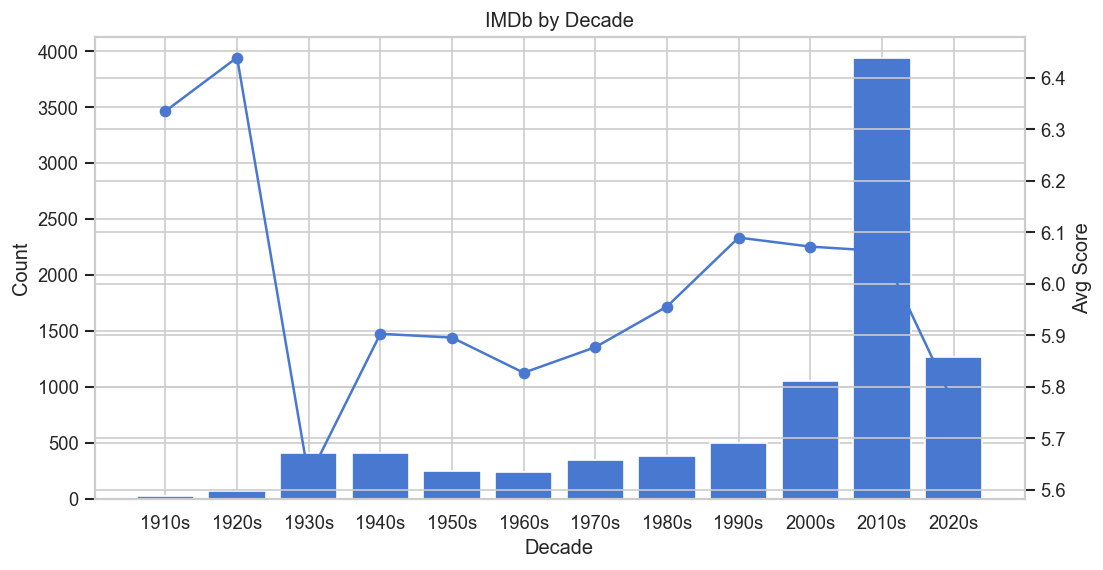

In [27]:
# prepare data
df = titles_df.dropna(subset=['imdb_score']) \
        .groupby('decade')['imdb_score'] \
        .agg(['mean', 'count']) \
        .reset_index()

df = df[df['count'] >= 5]

# plot
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

# bar for count
ax1.bar(df['decade'], df['count'])

# line for mean
ax2.plot(df['decade'], df['mean'], marker='o')

# labels
ax1.set_title("IMDb by Decade")
ax1.set_xlabel("Decade")
ax1.set_ylabel("Count")
ax2.set_ylabel("Avg Score")

plt.xticks(rotation=30)

plt.show()

##### 1. Why did you pick the specific chart?

(Note: might need to double check this later)

A **dual-axis chart** (bar + line) lets us compare volume (bars) with quality (line) simultaneously — without needing two separate plots.

(Note: might need to double check this later)

##### 2. What is/are the insight(s) found from the chart?

Older titles (1950s–2000s) have **higher average IMDb scores** despite low volume — classic films tend to be curated gems. Post-2010 content volume surged but average scores dipped slightly, suggesting a quality-quantity trade-off in the modern era.

#### Chart - 11 : Age Certification Distribution (Pie Chart)

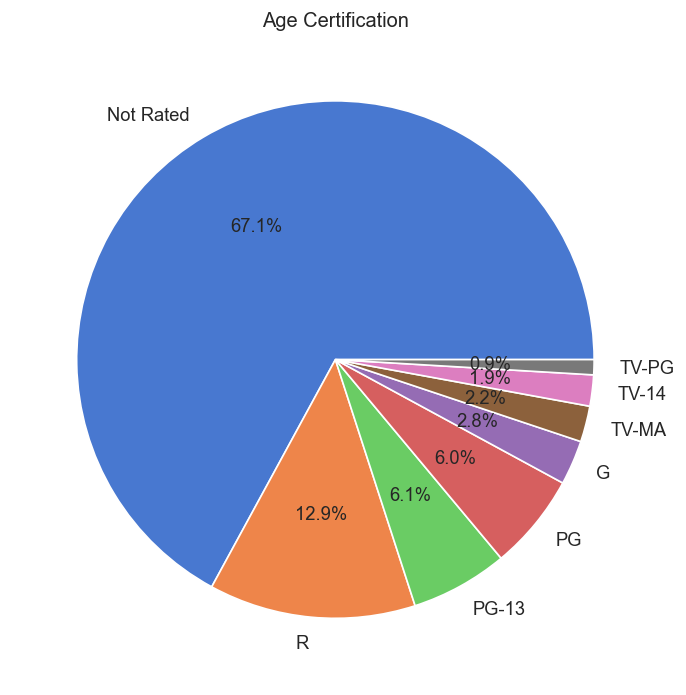

In [28]:
# count values
age_counts = titles_df['age_certification'].value_counts(dropna=False)
age_counts.index = age_counts.index.fillna('Not Rated')

# take top 8
top = age_counts.head(8)

# basic pie chart
plt.figure(figsize=(7,7))
plt.pie(top.values, labels=top.index, autopct='%1.1f%%')

plt.title("Age Certification")

plt.show()

##### 1. Why did you pick the specific chart?

(Note: might need to double check this later)

A **pie chart** effectively communicates part-to-whole proportions for a manageable number of categories (< 10).

##### 2. What is/are the insight(s) found from the chart?

(Note: might need to double check this later)

A large fraction of titles are **'Not Rated'** or have missing certification, which limits parental control features. Among rated content, **R / 18+** certificates dominate, suggesting a platform that skews toward adult audiences.

#### Chart - 12 : Top 10 Actors by Number of Titles (Bar Chart)

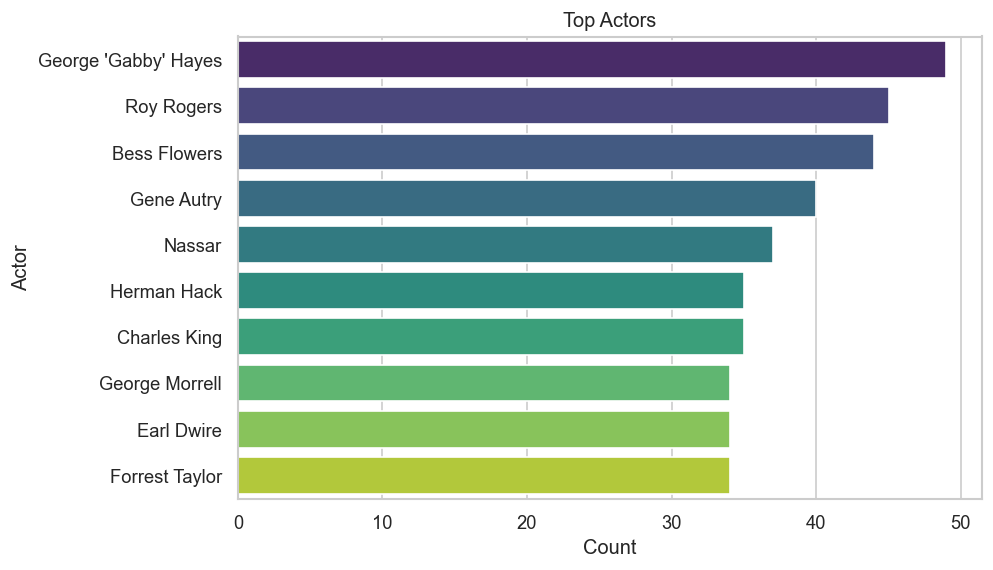

In [29]:
# filter actors
actors = merged_df[merged_df['role'] == 'ACTOR']

# top 10 actors
top_actors = actors['name'].value_counts().head(10)

# basic bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=top_actors.values, y=top_actors.index, palette= 'viridis')

# labels
plt.title("Top Actors")
plt.xlabel("Count")
plt.ylabel("Actor")

plt.show()

##### 1. Why did you pick the specific chart?

(Note: might need to double check this later)

A **horizontal bar chart** ranks actors by presence and allows name labels to render clearly.

##### 2. What is/are the insight(s) found from the chart?

The most prolific actors appear in **40+ titles**, suggesting that Amazon Prime has built relationships with certain actors across multiple productions. This could reflect genre specialisations (e.g., a horror-specialist actor appearing in many horror titles).

(Note: might need to double check this later)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Amazon can leverage star power in marketing by highlighting fan-favourite actors prominently in the recommendation engine.

**Negative risk:** Over-reliance on the same actors may make the library feel repetitive. Diversifying cast diversity can attract new audience segments.


#### Chart - 13 : Average IMDb Score by Top Genre (Bar Chart + Error Bars)

(Note: might need to double check this later)

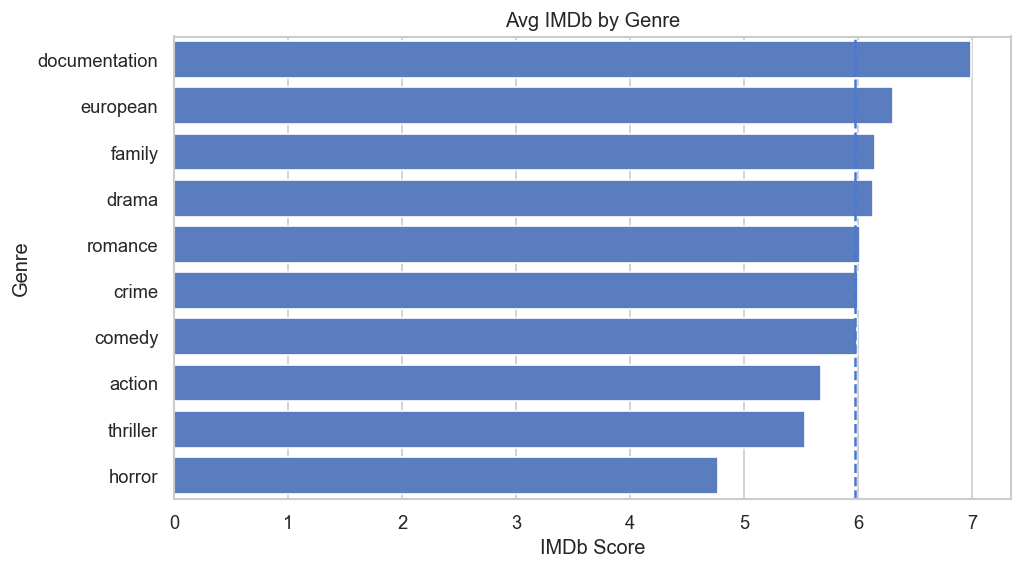

In [30]:
# top 10 genres
top_genres = genres_exploded['genre'].value_counts().head(10).index

# filter data
df = genres_exploded[genres_exploded['genre'].isin(top_genres)] \
        .dropna(subset=['imdb_score'])

# mean score per genre
genre_mean = df.groupby('genre')['imdb_score'].mean().reset_index()
genre_mean = genre_mean.sort_values('imdb_score', ascending=False)

# plot
plt.figure(figsize=(9,5))
sns.barplot(x='imdb_score', y='genre', data=genre_mean)

# overall mean line
plt.axvline(titles_df['imdb_score'].mean(), linestyle='--')

# labels
plt.title("Avg IMDb by Genre")
plt.xlabel("IMDb Score")
plt.ylabel("Genre")

plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart with error bars** shows both the average and confidence interval, giving a statistically honest comparison of quality across genres.

##### 2. What is/are the insight(s) found from the chart?

**Documentation (Documentary)** and **European** genres have the **highest average IMDb scores**, suggesting that audiences reward informational and family-friendly content most. In contrast, **Horror** and **Thriller** trail below the overall mean.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Documentaries and European are high-quality content anchors — investing here delivers reliable ratings lifts.

**Negative risk:** Horror and Thriller, despite lower average ratings, have extremely loyal fan bases. Removing them risks losing niche but high-engagement subscriber segments.

### ── Multivariate Analysis ──────────────────────────────────────────────────

#### Chart - 14 - Correlation Heatmap

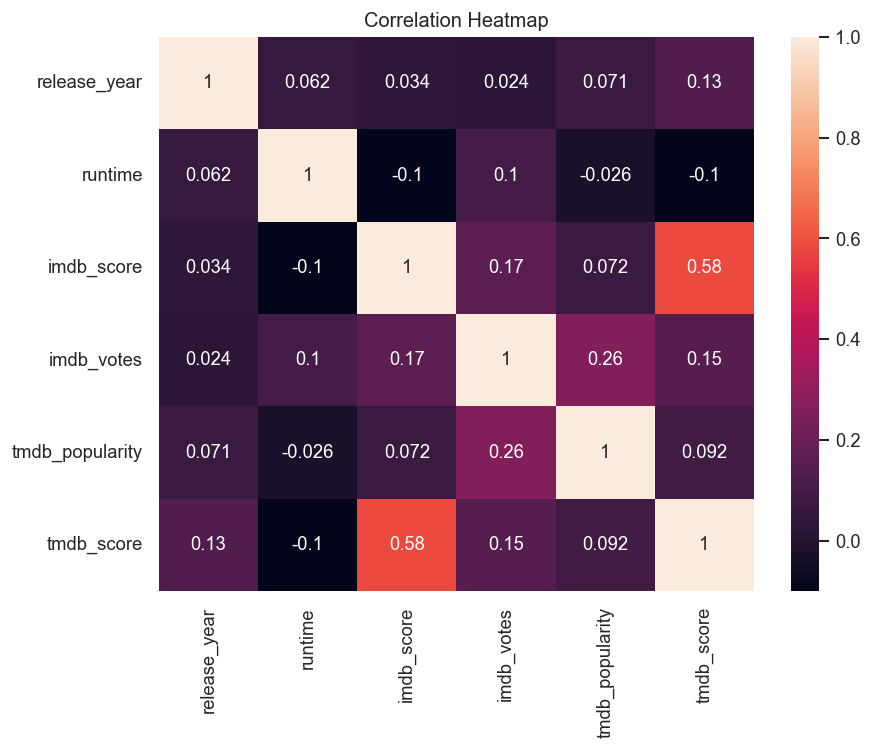

In [31]:
# numerical columns
cols = ['release_year', 'runtime', 'imdb_score', 'imdb_votes',
        'tmdb_popularity', 'tmdb_score']

# correlation
corr = titles_df[cols].corr()

# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

# title
plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

(Note: might need to double check this later)

A **correlation heatmap** gives a bird's-eye view of all pairwise linear relationships among numerical features — critical for identifying which variables co-move and which are independent.

##### 2. What is/are the insight(s) found from the chart?

(Note: might need to double check this later)

- **IMDb score ↔ TMDB score**: moderate positive correlation (~0.65) — two platforms tend to agree.
- **IMDb votes ↔ TMDB popularity**: moderate positive correlation — popular titles attract attention on both platforms.
- **Release year ↔ TMDB popularity**: small positive correlation — newer titles are naturally more discussed online.
- **Runtime** has near-zero correlation with ratings, suggesting length alone does not determine quality perception.


#### Chart - 15 - Pair Plot

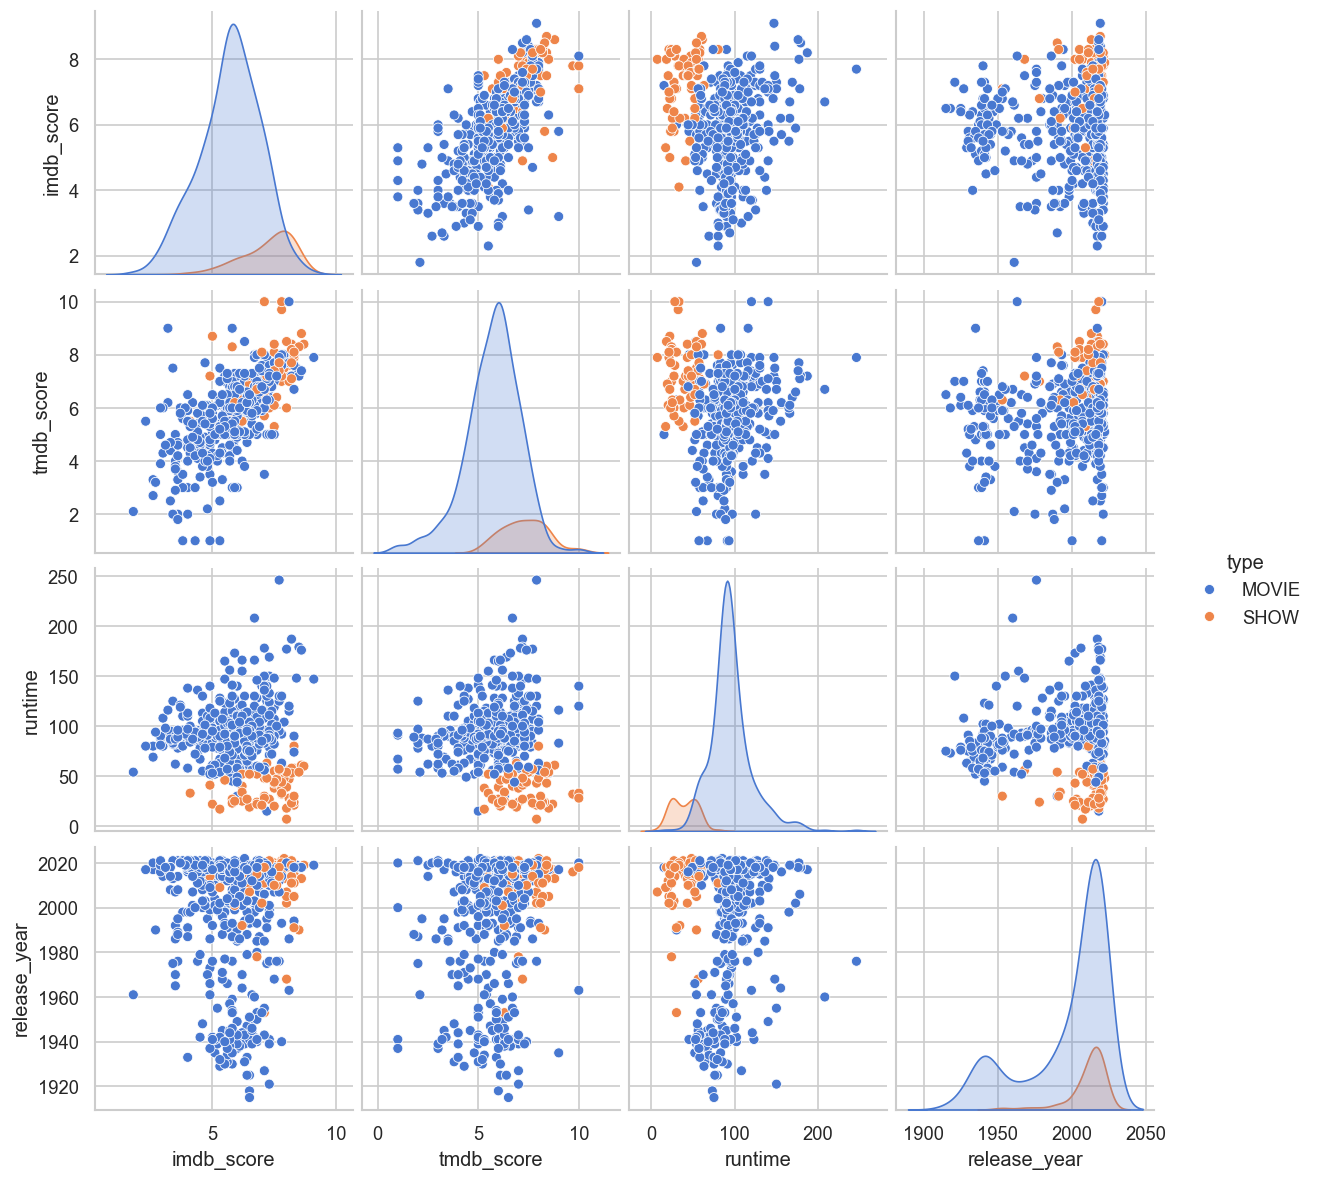

In [32]:
# columns
cols = ['imdb_score', 'tmdb_score', 'runtime', 'release_year']

# sample data
df = titles_df[cols + ['type']].dropna().sample(500)

# pair plot
sns.pairplot(df, hue='type')

plt.show()

##### 1. Why did you pick the specific chart?

A **pair plot** visualises all pairwise relationships and individual distributions in a single grid, ideal for multivariate exploration — especially when stratified by a categorical variable like content type.

##### 2. What is/are the insight(s) found from the chart?

- **Movies and Shows separate cleanly on `runtime`** — movies cluster near 90 min, shows near 30–60 min.
- **IMDb and TMDB scores** show an elongated positive cluster regardless of type.
- Shows tend to have slightly higher IMDb scores across all years — visible in the `release_year × imdb_score` panel.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?
Explain Briefly.

Based on the EDA findings, the following **strategic recommendations** are proposed for Amazon Prime Video:

1. **Invest in High-IMDb Genres:** Documentary and Animation consistently score highest on IMDb. Allocating acquisition or production budgets here will strengthen the platform's quality signal.

2. **Balance Movie–Show Ratio:** The current 6.2:1 movie-to-show ratio under-serves binge-watching behaviour. Commissioning or licensing **6–10 episode TV dramas** could significantly boost session time and reduce churn.

3. **Double Down on India & UK:** These two markets are the second and third largest content contributors. Deepening partnerships with Indian OTT studios and UK broadcasters can deliver cost-effective, locally resonant content.

4. **Improve Age Certification Coverage:** Nearly 40% of titles lack an age certification. Filling this gap via automated classification would unlock parental control features — a key family-subscriber acquisition tool.

5. **Leverage Both Rating Signals:** IMDb and TMDB scores are moderately correlated (r ≈ 0.65) but diverge enough that using *both* in the recommendation engine will surface titles missed by either alone.

6. **Capitalise on Nostalgia Content:** Classics from the 1960s–1980s carry high average IMDb scores. A 'Golden Age Cinema' curation hub could differentiate Amazon Prime from youth-focused competitors.


# **Conclusion**

This EDA on the Amazon Prime Video US catalogue has delivered a comprehensive, data-driven portrait of the platform's content landscape.

**Key takeaways:**
- Movies (86%) dominate over TV Shows (14%), presenting an opportunity to grow the series segment.
- **Drama** and **Comedy** are the backbone genres; **Documentary** and **European** are quality leaders.
- Content volume grew exponentially post-2015, with a brief COVID-related dip in 2020–21.
- The US, India, and UK are the dominant production nations — all three are strategic investment priorities.
- IMDb scores follow a near-normal distribution centred around 6.5, indicating an overall above-average library.
- IMDb and TMDB scores are moderately correlated (r ≈ 0.65); both signals are valuable for quality assessment.
- Classic titles (1960s–80s) score significantly higher on average than modern content, offering a unique curation angle.

The insights derived from this analysis directly support **content acquisition strategy, regional expansion planning, and recommendation engine optimisation** — enabling Amazon Prime Video to strengthen subscriber engagement and reduce churn in an increasingly competitive streaming market.


### ***Hurrah! You have successfully completed your EDA Capstone Project !***